# Лабораторная 7. Остаточные свёрточные сети. Дроп-аут. Батч-нормализация

**Задание.**

*1. Архитектура.* Реализовать свёрточную сеть с блоками слоёв с соединениями
напрямую (остаточными блоками). Использовать свёрточные блоки различной
архитектуры: 1) свёрточные блоки из предыдущего задания; 2) свёрточные блоки с
соединениями напрямую; 3) bottleneck-блоки (свёртки $1 \times 1$); и слои:
1) пакетной нормализации (batchnorm), 2) дроп-аута (dropout).

*2. Выборки.* Использовать выборку CIFAR-10 или др. (MNIST, FashionMNIST - для
сравнения). Для выбранного датасета подобрать параметры, при которых для
построенной архитектуры достигается наивысшее качество классификации. Сравнить с
результатами свёрточной сети (не остаточной) на тех же выборках.

*3. Гиперпараметры:* количество эпох; коэффициент обучения; количество скрытых
слоёв (количество остаточных блоков); количество каналов; параметры kernel,
stride, padding преобразований Conv2d и MaxPool2d; количество скрытых слоёв и
нейронов в многослойном перцептроне на выходе сети.

## 1. Теория

### Данные

Основная выборка FashionMNIST: изображения $28 \times 28$ в градациях серого,
10 классов одежды и обуви. MNIST используется для сравнения. Для перебора
гиперпараметров берётся 4000 обучающих и 1500 тестовых изображений, финальная
модель обучается на 12000 и проверяется на полной тестовой выборке из 10000.
Яркости делятся на 255 и нормируются средним и стандартным отклонением
обучающей выборки.

### Остаточный блок

Блок учит не искомое преобразование $H(x)$ целиком, а поправку к
тождественному:

$$y = F(x) + x, \qquad F(x) = H(x) - x .$$

При обратном распространении производная слагаемого $x$ равна единице, поэтому
градиент проходит через блок без затухания:

$$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I .$$

### Bottleneck-блок

Последовательность $1\times1 \to 3\times3 \to 1\times1$: свёртка $1\times1$
сжимает число каналов, дорогая свёртка $3\times3$ выполняется в узком
пространстве, затем каналы расширяются обратно. Свёртка $1\times1$ смешивает
только каналы и не смотрит на соседей по пространству.

### Батч-нормализация

Каждый канал нормируется по мини-батчу:

$$\hat z = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}, \qquad
  y = \gamma\hat z + \beta,$$

где $\mu_B$ и $\sigma_B^2$ считаются по батчу, а $\gamma$, $\beta$ обучаются. На
инференсе вместо статистик батча используются накопленные скользящие средние.

### Дроп-аут

При обучении обнуляется случайная доля $p$ активаций с масштабированием
оставшихся, на инференсе пропускается всё. `Dropout2d` выключает канал целиком.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| тип блока | plain, residual, bottleneck |
| число блоков | 2, 4, 6, 8 |
| батч-нормализация | есть, нет |
| дроп-аут | $0$, $0.2$, $0.5$ |
| число каналов | 16, 24, 32 |
| коэффициент обучения | $0.01$, $0.05$, $0.1$ |
| выходной перцептрон | без скрытых слоёв, $(64)$, $(128)$, $(128, 64)$ |

### Мера качества

Доля верных ответов accuracy, по классам precision, recall и $F_1$.

## 2. Данные

In [1]:
import os
import struct
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(20260905)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, устройство: {DEVICE}')

torch 2.11.0+cu128, устройство: cuda


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def find_dir(name, env):
    for c in [os.environ.get(env), f'../data/{name}/raw', f'data/{name}/raw',
              '../../bachelor/Perceptron/data_generation/MNIST/raw' if name == 'MNIST' else None]:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError(name)


FASHION_CLASSES = ['футболка', 'брюки', 'свитер', 'платье', 'пальто',
                   'сандалии', 'рубашка', 'кроссовки', 'сумка', 'ботинки']


def to_tensor(X, y, mean, std):
    """Изображения в тензор (N, 1, 28, 28) с нормировкой, метки в long."""
    t = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0  # ось 1 это канал
    t = (t - mean) / std
    return t.to(DEVICE), torch.tensor(y, dtype=torch.long).to(DEVICE)


def load(name, env, n_train, n_test, rng):
    """Подвыборка из датасета плюс сырые массивы для финальной модели."""
    D = find_dir(name, env)
    Xtr = read_idx(D / 'train-images-idx3-ubyte'); ytr = read_idx(D / 'train-labels-idx1-ubyte')
    Xte = read_idx(D / 't10k-images-idx3-ubyte'); yte = read_idx(D / 't10k-labels-idx1-ubyte')
    itr = rng.choice(len(Xtr), n_train, replace=False)
    ite = rng.choice(len(Xte), n_test, replace=False)
    mean, std = Xtr.mean() / 255.0, Xtr.std() / 255.0
    return (to_tensor(Xtr[itr], ytr[itr], mean, std),
            to_tensor(Xte[ite], yte[ite], mean, std),
            (Xtr, ytr, Xte, yte, mean, std))


(Xf, yf), (Xfv, yfv), fashion_full = load('FashionMNIST', 'FASHION_DIR', 4000, 1500,
                                          np.random.default_rng(20260905))
(Xm, ym), (Xmv, ymv), mnist_full = load('MNIST', 'MNIST_DIR', 4000, 1500,
                                        np.random.default_rng(20260905))
print(f'FashionMNIST: обучающая {tuple(Xf.shape)}, тестовая {tuple(Xfv.shape)}')
print(f'MNIST:        обучающая {tuple(Xm.shape)}, тестовая {tuple(Xmv.shape)}')

FashionMNIST: обучающая (4000, 1, 28, 28), тестовая (1500, 1, 28, 28)
MNIST:        обучающая (4000, 1, 28, 28), тестовая (1500, 1, 28, 28)


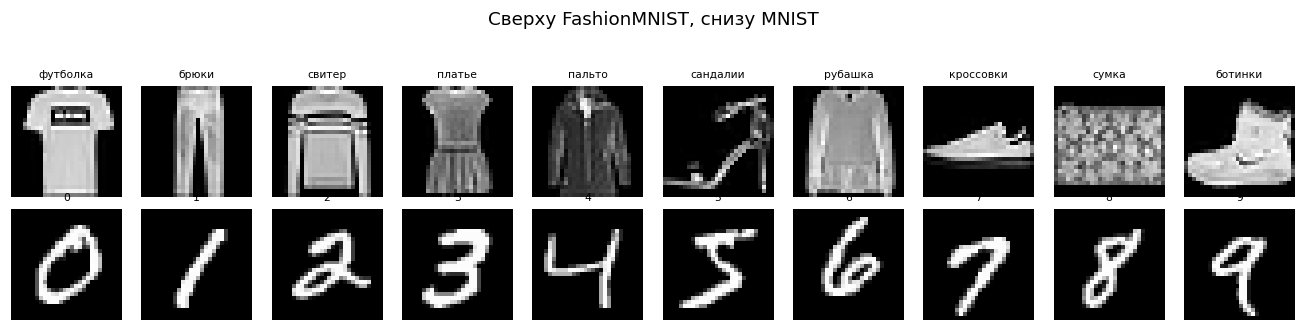

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
Xtr_raw, ytr_raw = fashion_full[0], fashion_full[1]
for c in range(10):
    j = np.flatnonzero(ytr_raw == c)[0]
    axes[0, c].imshow(Xtr_raw[j], cmap='gray'); axes[0, c].axis('off')
    axes[0, c].set_title(FASHION_CLASSES[c], fontsize=7)
Xm_raw, ym_raw = mnist_full[0], mnist_full[1]
for c in range(10):
    j = np.flatnonzero(ym_raw == c)[0]
    axes[1, c].imshow(Xm_raw[j], cmap='gray'); axes[1, c].axis('off')
    axes[1, c].set_title(str(c), fontsize=7)
fig.suptitle('Сверху FashionMNIST, снизу MNIST', y=1.06)
plt.tight_layout()
plt.show()

## 3. Блоки и сеть

In [4]:
def norm_layer(c, bn):
    """Батч-нормализация или пустышка, если нормализация выключена."""
    return nn.BatchNorm2d(c) if bn else nn.Identity()


class Block(nn.Module):
    """kind: plain - без соединения напрямую; residual - с соединением;
    bottleneck - свёртки 1x1 вокруг 3x3, с соединением."""

    def __init__(self, c, kind='plain', ks=3, bn=True, dropout=0.0):
        super().__init__()
        pad = ks // 2
        if kind == 'bottleneck':
            mid = max(4, c // 4)  # внутри блока число каналов сжимается вчетверо
            layers = [nn.Conv2d(c, mid, 1), norm_layer(mid, bn), nn.ReLU(),
                      nn.Conv2d(mid, mid, ks, 1, pad), norm_layer(mid, bn), nn.ReLU(),
                      nn.Conv2d(mid, c, 1)]
        else:
            layers = [nn.Conv2d(c, c, ks, 1, pad), norm_layer(c, bn), nn.ReLU(),
                      nn.Conv2d(c, c, ks, 1, pad)]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        layers.append(norm_layer(c, bn))  # нормализация стоит последней, до сложения
        self.body = nn.Sequential(*layers)
        self.kind = kind
        self.act = nn.ReLU()

    def forward(self, x):
        out = self.body(x)
        if self.kind in ('residual', 'bottleneck'):
            out = out + x  # соединение напрямую
        return self.act(out)


class Net(nn.Module):
    """Две стадии: стебель 28 на 14, блоки при C каналах, переход 14 на 7 с
    удвоением каналов, блоки при 2C, глобальный пуллинг и МСП."""

    def __init__(self, kind='plain', n_blocks=4, channels=16, ks=3,
                 bn=True, dropout=0.0, head=()):
        super().__init__()
        n1 = (n_blocks + 1) // 2  # блоки делятся между двумя стадиями поровну
        n2 = n_blocks - n1
        self.stem = nn.Sequential(nn.Conv2d(1, channels, 3, 1, 1), norm_layer(channels, bn),
                                  nn.ReLU(), nn.MaxPool2d(2, 2))
        self.stage1 = nn.Sequential(*[Block(channels, kind, ks, bn, dropout)
                                      for _ in range(n1)])
        self.transition = nn.Sequential(
            nn.Conv2d(channels, 2 * channels, 3, 1, 1), norm_layer(2 * channels, bn),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.stage2 = nn.Sequential(*[Block(2 * channels, kind, ks, bn, dropout)
                                      for _ in range(n2)])
        self.pool = nn.AdaptiveAvgPool2d(1)  # усреднение по всей карте признаков
        dims = [2 * channels] + list(head)
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], 10))
        self.head = nn.Sequential(*layers)

    def forward(self, x):
        z = self.stage2(self.transition(self.stage1(self.stem(x))))
        return self.head(self.pool(z).flatten(1))

In [5]:
def evaluate(model, X, y, batch=512):
    """Доля верных ответов, считается батчами."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for s in range(0, len(X), batch):
            correct += (model(X[s:s + batch]).argmax(1) == y[s:s + batch]).sum().item()
    return correct / len(X)


def run(model, Xtr, ytr, Xte, yte, lr=0.05, epochs=6, batch=64, seed=0):
    """Обучение с записью accuracy на обеих выборках после каждой эпохи."""
    torch.manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    lossf = nn.CrossEntropyLoss()
    test_hist, train_hist, t0 = [], [], time.time()
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr), device=Xtr.device)  # новый порядок объектов
        for s in range(0, len(Xtr), batch):
            b = perm[s:s + batch]
            opt.zero_grad()
            lossf(model(Xtr[b]), ytr[b]).backward()
            opt.step()
        test_hist.append(evaluate(model, Xte, yte))
        train_hist.append(evaluate(model, Xtr, ytr))
    return np.array(train_hist), np.array(test_hist), time.time() - t0


def n_params(m):
    return sum(p.numel() for p in m.parameters())

## 4. Главный эксперимент: глубина и тип блока

In [6]:
EPOCHS = 8
rows = []
t0 = time.time()
for kind, nb_ in itertools.product(['plain', 'residual', 'bottleneck'], [2, 4, 6, 8]):
    torch.manual_seed(20260905)
    model = Net(kind=kind, n_blocks=nb_, channels=24).to(DEVICE)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=0.05, epochs=EPOCHS)
    rows.append(dict(stage='глубина', dataset='FashionMNIST', kind=kind, n_blocks=nb_,
                     channels=24, bn=True, dropout=0.0, lr=0.05, head='()',
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
depth = pd.DataFrame(rows)
print(f'{len(depth)} конфигураций за {time.time() - t0:.0f} с')
depth.pivot_table(index='n_blocks', columns='kind', values=['train_acc', 'test_acc']).round(4)

12 конфигураций за 32 с


test_acc                   train_acc                 
kind     bottleneck   plain residual bottleneck   plain residual
n_blocks                                                        
2            0.8113  0.8353   0.8427     0.8395  0.8648   0.8692
4            0.8120  0.8420   0.8533     0.8252  0.8748   0.8882
6            0.8113  0.8247   0.8227     0.8585  0.8815   0.8722
8            0.8220  0.8147   0.8447     0.8590  0.8222   0.8830

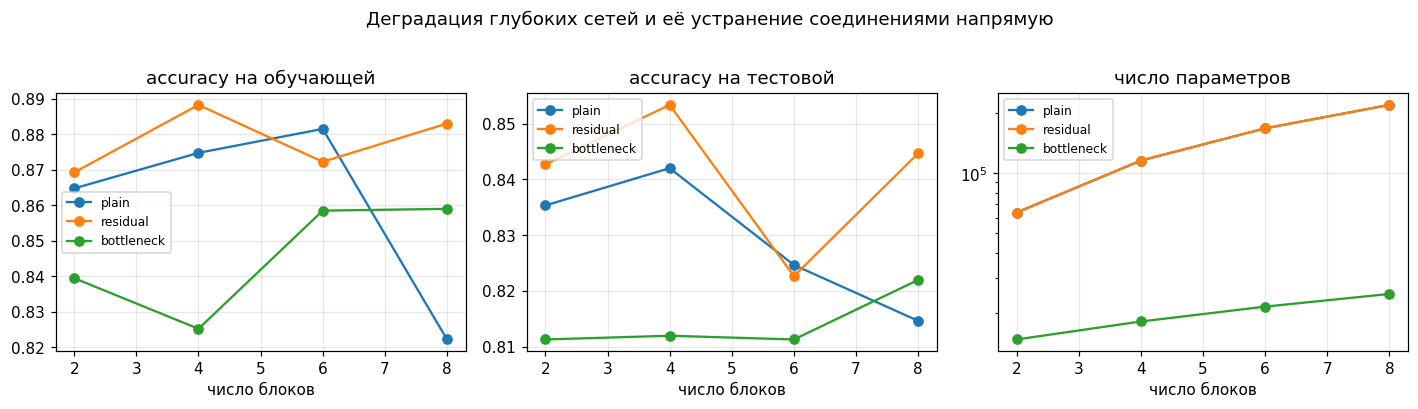

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for kind in ['plain', 'residual', 'bottleneck']:
    s = depth[depth.kind == kind].sort_values('n_blocks')
    axes[0].plot(s.n_blocks, s.train_acc, marker='o', label=kind)
    axes[1].plot(s.n_blocks, s.test_acc, marker='o', label=kind)
    axes[2].plot(s.n_blocks, s.params, marker='o', label=kind)
axes[0].set_title('accuracy на обучающей'); axes[1].set_title('accuracy на тестовой')
axes[2].set_title('число параметров'); axes[2].set_yscale('log')
for ax in axes:
    ax.set_xlabel('число блоков'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Деградация глубоких сетей и её устранение соединениями напрямую', y=1.02)
plt.tight_layout()
plt.show()

## 5. Батч-нормализация и дроп-аут

In [8]:
best_depth = depth.sort_values('test_acc', ascending=False).iloc[0]
KIND, NB = best_depth['kind'], int(best_depth['n_blocks'])
print(f'лучшая пара: {KIND}, {NB} блоков, accuracy {best_depth["test_acc"]:.4f}')

rows = []
for bn, dp in itertools.product([True, False], [0.0, 0.2, 0.5]):
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=24, bn=bn, dropout=dp).to(DEVICE)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=0.05, epochs=EPOCHS)
    rows.append(dict(stage='bn и dropout', dataset='FashionMNIST', kind=KIND,
                     n_blocks=NB, channels=24, bn=bn, dropout=dp, lr=0.05, head='()',
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
regu = pd.DataFrame(rows)
regu['разрыв'] = (regu.train_acc - regu.test_acc).round(4)
print(regu[['bn', 'dropout', 'train_acc', 'test_acc', 'разрыв', 'time']].round(4).to_string(index=False))

лучшая пара: residual, 4 блоков, accuracy 0.8533


   bn  dropout  train_acc  test_acc  разрыв  time
 True      0.0     0.8888    0.8473  0.0414   2.2
 True      0.2     0.8368    0.8247  0.0121   2.3
 True      0.5     0.8122    0.7933  0.0189   2.3
False      0.0     0.8318    0.8113  0.0204   1.6
False      0.2     0.8185    0.8047  0.0138   1.7
False      0.5     0.7790    0.7587  0.0203   1.7


## 6. Каналы, коэффициент обучения и выходной перцептрон

In [9]:
best_regu = regu.sort_values('test_acc', ascending=False).iloc[0]
BN, DP = bool(best_regu['bn']), float(best_regu['dropout'])
print(f'выбраны batchnorm={BN}, dropout={DP}')

rows = []
for ch, lr in itertools.product([16, 24, 32], [0.01, 0.05, 0.1]):
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=ch, bn=BN, dropout=DP).to(DEVICE)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=lr, epochs=EPOCHS)
    rows.append(dict(stage='каналы и lr', dataset='FashionMNIST', kind=KIND,
                     n_blocks=NB, channels=ch, bn=BN, dropout=DP, lr=lr, head='()',
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
chan = pd.DataFrame(rows)
chan.pivot_table(index='channels', columns='lr', values='test_acc').round(4)

выбраны batchnorm=True, dropout=0.0


lr,0.01,0.05,0.10
channels,,,
16,0.8093,0.8027,0.8333
24,0.7880,0.8340,0.8453
32,0.8140,0.8087,0.8533


In [10]:
best_ch = chan.sort_values('test_acc', ascending=False).iloc[0]
CH, LR = int(best_ch['channels']), float(best_ch['lr'])
print(f'выбраны каналов {CH}, lr {LR}')

HEAD_OPTIONS = [(), (64,), (128,), (128, 64)]
HEAD_BY_NAME = {str(h): h for h in HEAD_OPTIONS}  # чтобы вернуть кортеж по строке из таблицы

rows = []
for head in HEAD_OPTIONS:
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=CH, bn=BN, dropout=DP, head=head).to(DEVICE)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=LR, epochs=EPOCHS)
    rows.append(dict(stage='голова', dataset='FashionMNIST', kind=KIND, n_blocks=NB,
                     channels=CH, bn=BN, dropout=DP, lr=LR, head=str(head),
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
heads = pd.DataFrame(rows)
print(heads[['head', 'train_acc', 'test_acc', 'params', 'time']].round(4).to_string(index=False))

выбраны каналов 32, lr 0.1


     head  train_acc  test_acc  params  time
       ()     0.8938    0.8393  205130   2.3
    (64,)     0.8075    0.8033  209290   2.3
   (128,)     0.8458    0.8093  214090   2.4
(128, 64)     0.7772    0.7667  221706   2.5


## 7. Сравнение остаточной и обычной сети на обеих выборках

In [11]:
allres = pd.concat([depth, regu.drop(columns='разрыв'), chan, heads], ignore_index=True)
best = allres.sort_values('test_acc', ascending=False).iloc[0]
HEAD = HEAD_BY_NAME[best['head']]
print('лучшая конфигурация:')
for k in ['kind', 'n_blocks', 'channels', 'bn', 'dropout', 'lr', 'head']:
    print(f'  {k}: {best[k]}')

rows = []
for ds, (Xa, ya, Xb, yb) in [('FashionMNIST', (Xf, yf, Xfv, yfv)),
                             ('MNIST', (Xm, ym, Xmv, ymv))]:
    for kind in ['plain', 'residual']:
        torch.manual_seed(20260905)
        model = Net(kind=kind, n_blocks=NB, channels=CH, bn=BN, dropout=DP,
                    head=HEAD).to(DEVICE)
        tr, te, dt = run(model, Xa, ya, Xb, yb, lr=LR, epochs=EPOCHS)
        rows.append(dict(dataset=ds, kind=kind, test_acc=float(te.max()),
                         train_acc=float(tr[-1]), params=n_params(model),
                         time=round(dt, 1)))
cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))

лучшая конфигурация:
  kind: residual
  n_blocks: 4
  channels: 24
  bn: True
  dropout: 0.0
  lr: 0.05
  head: ()


     dataset     kind  test_acc  train_acc  params  time
FashionMNIST    plain    0.8160     0.8565  205130   2.2
FashionMNIST residual    0.8447     0.8790  205130   2.4
       MNIST    plain    0.9820     0.9940  205130   2.2
       MNIST residual    0.9733     0.9945  205130   2.3


31 конфигураций сохранено в results.csv


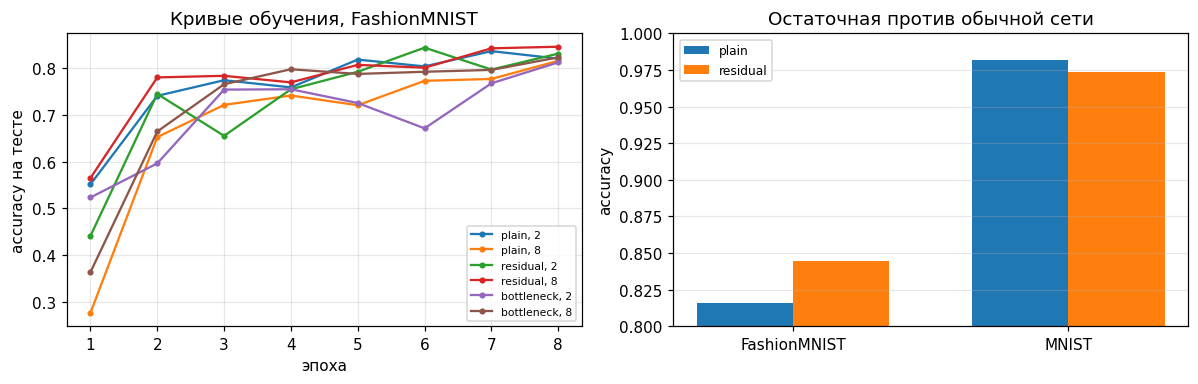

In [12]:
allres.drop(columns='curve').to_csv('results.csv', index=False)
print(f'{len(allres)} конфигураций сохранено в results.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for kind in ['plain', 'residual', 'bottleneck']:
    for nb_ in [2, 8]:
        s = depth[(depth.kind == kind) & (depth.n_blocks == nb_)]
        if len(s):
            axes[0].plot(range(1, EPOCHS + 1), s.iloc[0]['curve'],
                         marker='o', ms=3, label=f'{kind}, {nb_}')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на тесте')
axes[0].set_title('Кривые обучения, FashionMNIST'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)

xs = np.arange(len(cmp) // 2)
w = 0.35
for i, kind in enumerate(['plain', 'residual']):
    s = cmp[cmp.kind == kind]
    axes[1].bar(xs + (i - 0.5) * w, s.test_acc.values, w, label=kind)
axes[1].set_xticks(xs); axes[1].set_xticklabels(cmp.dataset.unique())
axes[1].set_ylim(0.8, 1.0); axes[1].set_ylabel('accuracy')
axes[1].set_title('Остаточная против обычной сети'); axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Финальная модель на выборке большего размера

In [13]:
Xtr_raw, ytr_raw, Xte_raw, yte_raw, mean, std = fashion_full
idx = RNG.choice(len(Xtr_raw), 12000, replace=False)
Xb, yb = to_tensor(Xtr_raw[idx], ytr_raw[idx], mean, std)
Xt, yt = to_tensor(Xte_raw, yte_raw, mean, std)

torch.manual_seed(20260905)
final = Net(kind=KIND, n_blocks=NB, channels=CH, bn=BN, dropout=DP, head=HEAD).to(DEVICE)
tr_h, te_h, dt = run(final, Xb, yb, Xt, yt, lr=LR, epochs=12)
print(f'обучение на 12000 изображениях, 12 эпох: {dt:.0f} с')
print(f'accuracy на полной тестовой выборке FashionMNIST: {te_h[-1]:.4f}')
print(f'число параметров: {n_params(final):,}')

обучение на 12000 изображениях, 12 эпох: 11 с
accuracy на полной тестовой выборке FashionMNIST: 0.8836
число параметров: 205,130


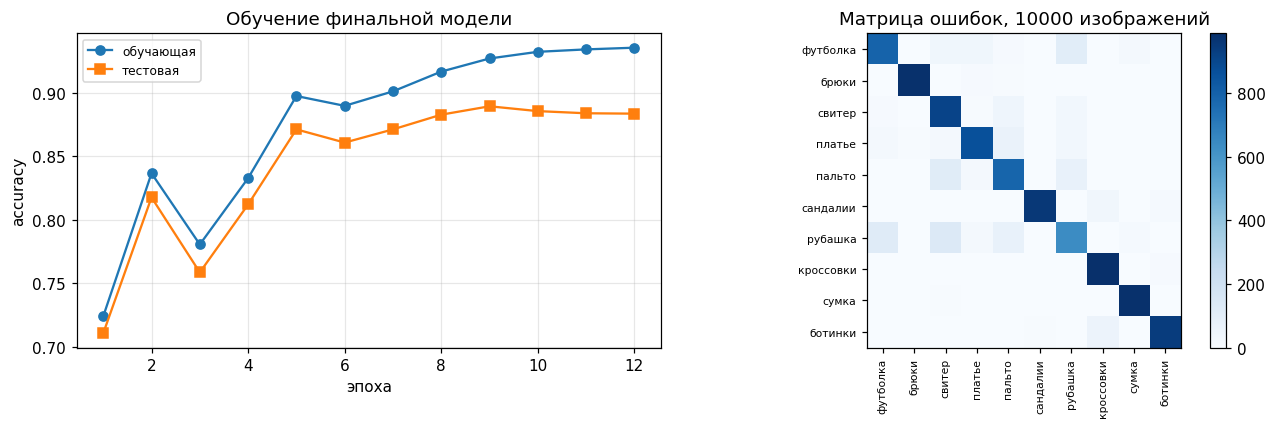

              precision    recall  f1-score   support

    футболка      0.850     0.794     0.821      1000
       брюки      0.986     0.983     0.984      1000
      свитер      0.748     0.910     0.821      1000
      платье      0.900     0.864     0.882      1000
      пальто      0.799     0.785     0.792      1000
    сандалии      0.989     0.953     0.970      1000
     рубашка      0.725     0.638     0.679      1000
   кроссовки      0.918     0.987     0.951      1000
       сумка      0.960     0.982     0.971      1000
     ботинки      0.972     0.940     0.956      1000

    accuracy                          0.884     10000
   macro avg      0.885     0.884     0.883     10000
weighted avg      0.885     0.884     0.883     10000



In [14]:
from sklearn.metrics import confusion_matrix, classification_report

final.eval()
with torch.no_grad():  # предсказания считаются батчами и переносятся на CPU
    pred = torch.cat([final(Xt[s:s + 512]).argmax(1)
                      for s in range(0, len(Xt), 512)]).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 13), tr_h, marker='o', label='обучающая')
axes[0].plot(range(1, 13), te_h, marker='s', label='тестовая')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy')
axes[0].set_title('Обучение финальной модели'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

cm = confusion_matrix(yte_raw, pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_xticklabels(FASHION_CLASSES, rotation=90, fontsize=7)
axes[1].set_yticklabels(FASHION_CLASSES, fontsize=7)
axes[1].set_title('Матрица ошибок, 10000 изображений')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(classification_report(yte_raw, pred, target_names=FASHION_CLASSES, digits=3))